### 例 18.6 解析  
**题目**：利用文件 `austa.csv`（共 31 个数据，格式含日期与对应值 ），建立合适的 ARIMA 模型。  

**步骤与解析**：  
1. **数据预处理与平稳性探索**  
    - 先对原始数据做一次差分（图 18.8 左），结合差分后数据的自相关图（图 18.8 右 ），初步分析序列平稳性，为确定 ARIMA 模型的差分阶数 \(d\) 提供依据。  
2. **模型定阶（确定 \(p,q\) ）**  
    - 通过尝试不同 \(p\)（自回归阶数 ）、\(q\)（移动平均阶数 ）组合，依据 AIC（赤池信息准则 ）、BIC（贝叶斯信息准则 ）等指标，选定构建 \( \text{ARIMA}(2,1,0) \) 模型（即自回归阶数 \(p=2\)、差分阶数 \(d=1\)、移动平均阶数 \(q=0\)  ）。  
3. **模型拟合与残差分析**  
    - 用 Python 拟合 \( \text{ARIMA}(2,1,0) \) 模型，得到残差（预测值与实际值的差值 ）结果。图 18.9 展示残差取值（左，看残差波动 ）和分布（右，看是否近似正态等 ），若残差特性良好（如近似白噪声 ），说明模型拟合效果佳。  
4. **预测与效果验证**  
    - 基于拟合模型预测，将预测值与原始数据对比（图 18.10 ），直观呈现模型对数据的拟合及预测能力，辅助判断模型适用性。  

简言之，就是先处理数据看平稳性，再选阶、拟合、分析残差，最后用模型预测并验证，完成 ARIMA 建模流程来适配 `austa.csv` 数据规律 。

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   31
Model:                 ARIMA(2, 1, 0)   Log Likelihood                   5.753
Date:                Sun, 24 Aug 2025   AIC                             -5.507
Time:                        15:57:12   BIC                             -1.303
Sample:                             0   HQIC                            -4.162
                                 - 31                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4962      0.196      2.532      0.011       0.112       0.880
ar.L2          0.0485      0.215      0.225      0.822      -0.373       0.470
sigma2         0.0395      0.012      3.193      0.0

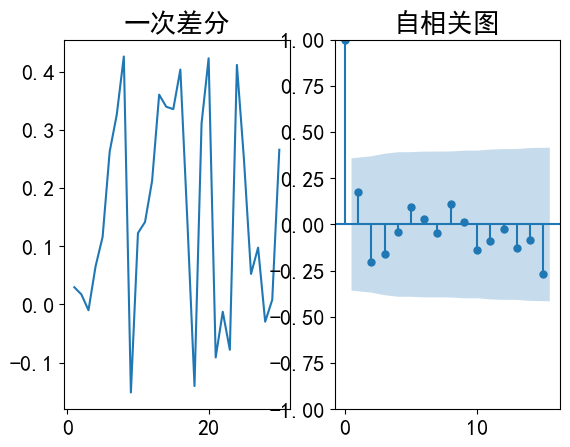

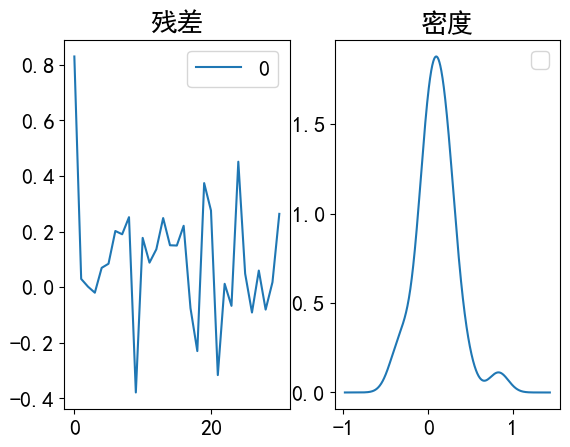

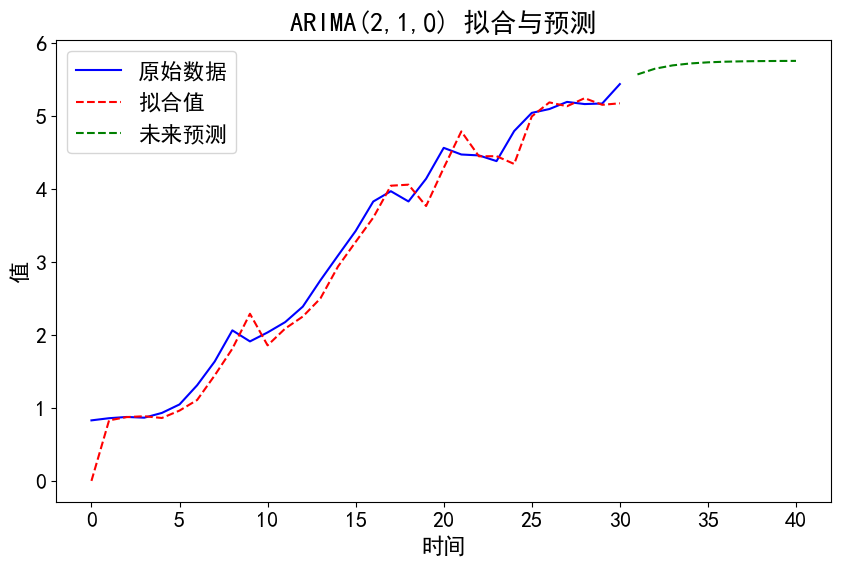

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ARIMA
from statsmodels.graphics.tsaplots import plot_acf

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 16

df = pd.read_csv('austa.csv')
plt.subplot(121)
plt.plot(df.value.diff())   
plt.title('一次差分')

ax2 = plt.subplot(122)
plot_acf(df.value.diff().dropna(), ax=ax2, title='自相关图')

md = ARIMA(df.value, order=(2, 1, 0))
mdf = md.fit()
print(mdf.summary())

residuals = pd.DataFrame(mdf.resid)  # 残差
fig, ax = plt.subplots(1, 2)
residuals.plot(title="残差", ax=ax[0])
residuals.plot(kind='kde', title='密度', ax=ax[1])
plt.legend('')
plt.ylabel('')

pred = mdf.predict(start=0, end=len(df.value)-1)
forecast = mdf.forecast(steps=10)  # 预测未来 10 步（可调整）
# 绘制原始数据与预测值对比图
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.value, label='原始数据', color='blue')
plt.plot(df.index, pred, label='拟合值', color='red', linestyle='--')
plt.plot(range(len(df.value), len(df.value) + len(forecast)), forecast, label='未来预测', color='green', linestyle='--')
plt.title('ARIMA(2,1,0) 拟合与预测')
plt.xlabel('时间')
plt.ylabel('值')
plt.legend()
plt.show()

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-14.764, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-14.309, Time=0.01 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-13.089, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-13.719, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-12.645, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-13.534, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-11.848, Time=0.05 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-9.851, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-11.784, Time=0.02 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-9.850, Time=0.06 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-7.859, Time=0.07 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.427 seconds
Best model order: (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                  value   No.

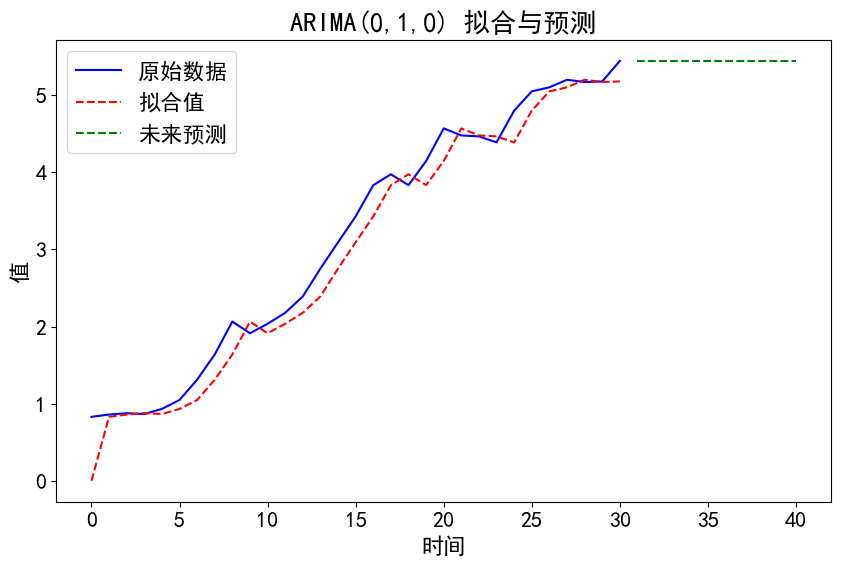

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 16

# 加载数据
df = pd.read_csv('austa.csv')

# 自动搜索最优参数
model = pm.auto_arima(df.value, start_p=0, max_p=3, start_q=0, max_q=2, d=1, 
                      seasonal=False, trace=True, stepwise=False, max_order=5)
print(f"Best model order: {model.order}")  # 输出最优 (p, d, q)

# 使用 auto_arima 选择的最优参数创建模型
md = ARIMA(df.value, order=model.order)
mdf = md.fit()
print(mdf.summary())

# 预测值
pred = mdf.predict(start=0, end=len(df.value)-1)
forecast = mdf.forecast(steps=10)  # 预测未来 10 步

# 绘制对比图
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.value, label='原始数据', color='blue')
plt.plot(df.index, pred, label='拟合值', color='red', linestyle='--')
plt.plot(range(len(df.value), len(df.value) + len(forecast)), forecast, label='未来预测', color='green', linestyle='--')
plt.title(f'ARIMA({model.order[0]},{model.order[1]},{model.order[2]}) 拟合与预测')
plt.xlabel('时间')
plt.ylabel('值')
plt.legend()
plt.show()